# EDA: German Electricity Consumption

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/opsd_germany_daily.csv', index_col=0, parse_dates=True)
df.head()

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN
2006-01-04,1457.217,NaN,NaN,NaN
2006-01-05,1477.131,NaN,NaN,NaN


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(4383, 4)
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64
dtype: object
Consumption       0
Wind           1463
Solar          2195
Wind+Solar     2196
dtype: int64


In [3]:
print(f"Date range: {df.index.min()} to {df.index.max()}")
print()
print(df['Consumption'].describe())

Date range: 2006-01-01 00:00:00 to 2017-12-31 00:00:00

count    4383.000000
mean     1338.675836
std       165.775710
min       842.395000
25%      1217.859000
50%      1367.123000
75%      1457.761000
max      1709.568000
Name: Consumption, dtype: float64


## Consumption over time

Strong seasonal pattern as expected : Germany runs significantly higher consumption in winter. 
The weekly rhythm is also visible. 
Some isolated sharp drops are probably public holidays (Christmas etc).

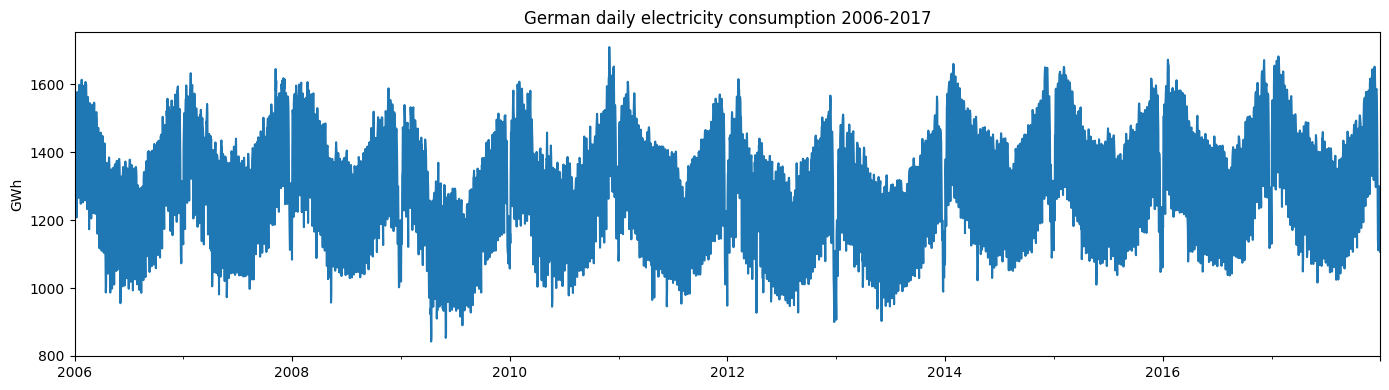

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
df['Consumption'].plot(ax=ax)
ax.set_title('German daily electricity consumption 2006-2017')
ax.set_ylabel('GWh')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Weekly pattern

Weekdays are pretty flat around 1400 GWh, then it drops off on Saturday and Sunday. 
Sunday is the lowest. 

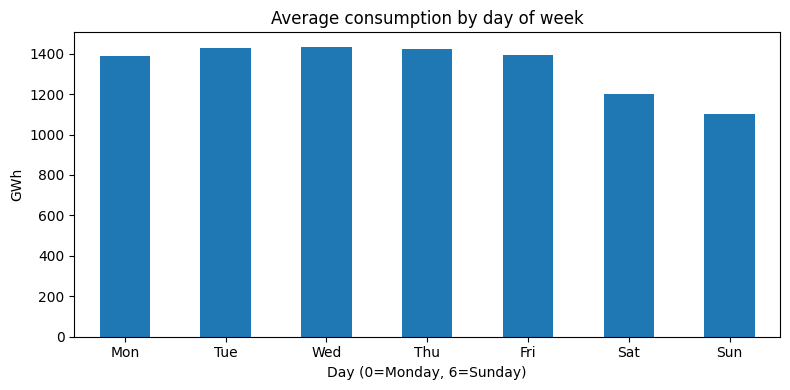

In [5]:
df['dayofweek'] = df.index.dayofweek

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('dayofweek')['Consumption'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average consumption by day of week')
ax.set_xlabel('Day (0=Monday, 6=Sunday)')
ax.set_ylabel('GWh')
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)
plt.tight_layout()
plt.show()

## Monthly pattern

Winter months (Jan/Feb) are highest, summer (Aug) lowest, but only about 200 GWh difference. December is lower than Jan/Feb, probably holiday shutdowns.

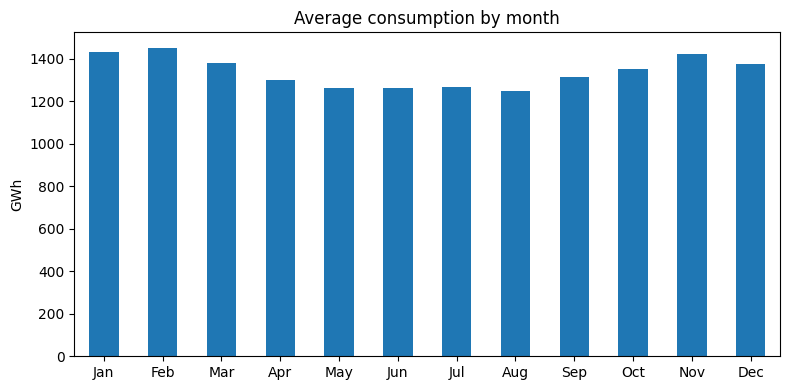

In [6]:
df['month'] = df.index.month

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('month')['Consumption'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average consumption by month')
ax.set_xlabel('')
ax.set_ylabel('GWh')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

## Feature Engineering

Adding time-based and lag features for the forecasting models.

In [7]:
# create a clean copy for modelling
data = df[['Consumption']].copy()

# time features
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['is_weekend'] = (data.index.dayofweek >= 5).astype(int)

# lag features — yesterday and last week
data['lag_1'] = data['Consumption'].shift(1)
data['lag_7'] = data['Consumption'].shift(7)

# rolling average — last 7 days
data['rolling_7'] = data['Consumption'].shift(1).rolling(7).mean()

# drop rows with NaN from lag/rolling
data = data.dropna()

print(data.shape)
data.head()

(4376, 7)


,Consumption,dayofweek,month,is_weekend,lag_1,lag_7,rolling_7
Date,,,,,,,
2006-01-08,1207.985,6,1,1,1300.287,1069.184,1361.471429
2006-01-09,1529.323,0,1,0,1207.985,1380.521,1381.300143
2006-01-10,1576.911,1,1,0,1529.323,1442.533,1402.557571
2006-01-11,1577.176,2,1,0,1576.911,1457.217,1421.754429
2006-01-12,1553.280,3,1,0,1577.176,1477.131,1438.891429


In [8]:
# use last year (2017) as test set, everything before as training
train = data[data.index.year < 2017]
test = data[data.index.year == 2017]

print(f"Train: {train.shape[0]} rows ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {test.shape[0]} rows ({test.index.min().date()} to {test.index.max().date()})")

Train: 4011 rows (2006-01-08 to 2016-12-31)
Test:  365 rows (2017-01-01 to 2017-12-31)


In [9]:
features = ['dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_7', 'rolling_7']
target = 'Consumption'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(X_train.shape, X_test.shape)

(4011, 6) (365, 6)


## Model 1: Moving Average Baseline

Simple baseline: predict tomorrow's consumption as the average of the last 7 days.
No ML, just a sanity check to beat.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# moving average prediction = rolling_7 feature (already computed)
ma_pred = test['rolling_7']

mae_ma = mean_absolute_error(y_test, ma_pred)
rmse_ma = np.sqrt(mean_squared_error(y_test, ma_pred))

print(f"Moving Average — MAE: {mae_ma:.2f}, RMSE: {rmse_ma:.2f}")

Moving Average — MAE: 122.06, RMSE: 140.21


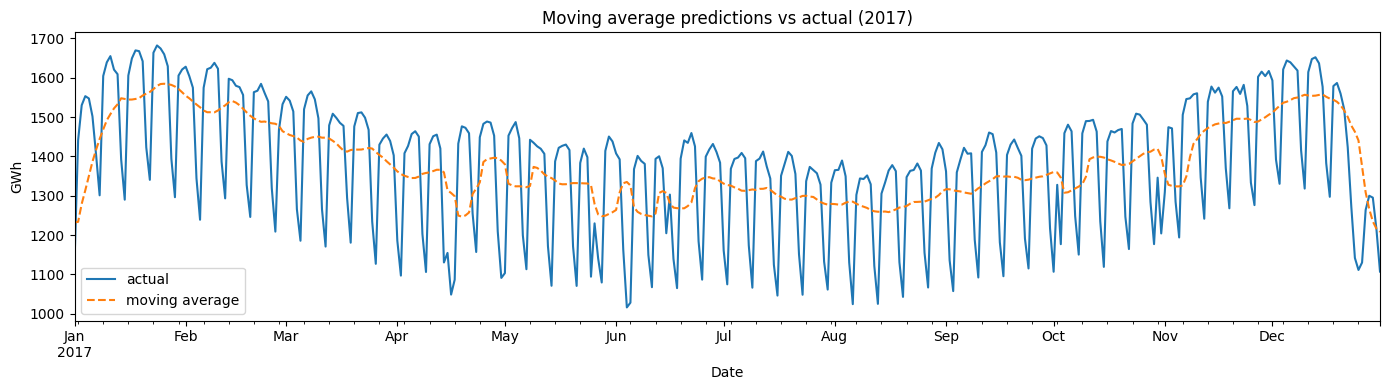

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
y_test.plot(ax=ax, label='actual')
ma_pred.plot(ax=ax, label='moving average', linestyle='--')
ax.set_title('Moving average predictions vs actual (2017)')
ax.set_ylabel('GWh')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Moving average results

MAE: 122 GWh, RMSE: 140 GWh. The seasonal trend is captured reasonably well but the 
weekly cycle is completely missed — the prediction is too smooth. It has no way of knowing 
whether a given day is a Monday or Sunday, which matters a lot for consumption.
This is the baseline to beat.